#Génération Musicale par Émotion avec VAE & CVAE

### **Sommaire**:

Ce notebook implémente un pipeline complet de **génération musicale conditionnée par l'émotion** :

1. **Importer** les fichiers MIDI du dataset EMOPIA (1078 clips annotés par émotion)
2. **Tokeniser** ces fichiers avec MidiTok (tokenizer REMI) pour obtenir des séquences discrètes
3. **Entraîner un VAE** (Variational Auto-Encoder) pour apprendre un espace latent structuré (en fonction de différents modèles testés)
4. **Améliorer en CVAE** (Conditional VAE) pour conditionner la génération par émotion (avec le meilleur modèle obtenu)
5. **Visualiser** l'espace latent, les distributions, et les clusters par émotion
6. **Générer** de nouveaux fichiers MIDI pour chaque émotion

### Le dataset EMOPIA

EMOPIA (Emotion in Pop music with Aligned Audio) contient des clips de piano pop annotés
selon le modèle de Russell (Valence × Arousal) en **4 quadrants** :

| Quadrant | Valence | Arousal | Émotion typique |
|----------|---------|---------|-----------------|
| **Q1** | Positive | Haute | Joyeux, énergique |
| **Q2** | Positive | Basse | Tendu, dramatique  |
| **Q3** | Négative | Basse | Triste, mélancolique |
| **Q4** | Négative | Haute | Serein, paisible|

### Dossier des données

**Sur Google Colab** : uploadez le dossier `EMOPIA_1.0` dans votre Google Drive (ex: `Mon Drive/EMOPIA_1.0/`). Le notebook montera automatiquement le Drive.


## 1. Installation & Imports



In [ ]:
# Installation des packages (nécessaire sur Colab) #pour la tokenisation des fichiers MIDI
!pip install -q miditok symusic torch matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 70.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
import os
from collections import Counter

#on importe les fichiers MIDI du dossier Drive

# !! Chemin à adapter !!
data_path = "/content/drive/MyDrive/projet_emopia/dataset"


midi_files = []
for f in sorted(os.listdir(data_path)):
    if not (f.endswith(".mid") or f.endswith(".midi")):
        continue
    label = None
    for q in ["Q1","Q2","Q3","Q4"]:
        if f.upper().startswith(q):
            label = q; break
    if label:
        midi_files.append((os.path.join(data_path, f), label))
    else:
        print(f"⚠️  Ignoré : {f}")

counts = Counter(l for _, l in midi_files)
print(f" {len(midi_files)} fichiers :")
for q in ["Q1","Q2","Q3","Q4"]:
    print(f"  {q} : {counts.get(q, 0)} fichiers")

 1078 fichiers :
  Q1 : 250 fichiers
  Q2 : 265 fichiers
  Q3 : 253 fichiers
  Q4 : 310 fichiers


In [ ]:
import os, glob, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from collections import Counter

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

Device utilisé : cuda


## 2. Tokenisation MIDI avec MidiTok (REMI)

Les fichiers MIDI contiennent des événements continus (note on/off, velocité, temps).
Pour les traiter avec un réseau de neurones, on les convertit en séquences de tokens discrets, comme on le fait pour le texte en NLP.

On utilise le tokenizer **REMI** (REvamped MIDI representation) de la bibliothèque Miditok car:
- Représente la musique comme une séquence de tokens : `Bar`, `Position`, `Pitch`, `Velocity`, `Duration`
- Capture la structure temporelle (mesures, positions dans la mesure)
- Est bien adapté aux modèles séquentiels (Transformers, VAE)

**Exemple de tokenisation** : une note Do4 jouée forte au début de la mesure donne :
```
[Bar_0] [Position_0] [Pitch_60] [Velocity_12] [Duration_2.0]
```

Chaque fichier MIDI devient une séquence de ~100 à 3000 tokens (selon la durée du clip).

In [ ]:
from miditok import REMI, TokenizerConfig
from symusic import Score

# 16 niveaux de vélocité, pas d'accords ni de multi-piste
config = TokenizerConfig(num_velocities=16, use_chords=False, use_programs=False)
tokenizer = REMI(config)

def tokenize_midi_files(data_dir, tokenizer, max_files=None):
    """
    On tokenise tous les fichiers MIDI du dossier.
    On extrait automatiquement le label d'émotion depuis le nom du fichier (Q1_xxx.mid --> label 0).
    """
    midi_files = sorted(glob.glob(os.path.join(data_dir, "*.mid")))
    if max_files:
        random.seed(42)
        midi_files = random.sample(midi_files, min(max_files, len(midi_files)))

    all_tokens, all_labels = [], []
    errors = 0
    for fp in midi_files:
        fname = os.path.basename(fp)
        try:
            q_num = int(fname[1])   # Q1-->1, Q2-->2, Q3-->3, Q4-->4
            label = q_num - 1
        except:
            continue
        try:
            score = Score(fp)
            tok_result = tokenizer(score)
            for ts in tok_result:
                ids = ts.ids
                if len(ids) >= 20:  # ignorer les séquences trop courtes (< 20 tokens)
                    all_tokens.append(ids)
                    all_labels.append(label)
        except Exception:
            errors += 1

    print(f"Tokenisation terminée: {len(all_tokens)} séquences depuis {len(midi_files)} fichiers ({errors} erreurs)")
    return all_tokens, all_labels

all_tokens, all_labels = tokenize_midi_files(data_path, tokenizer)

Tokenisation terminée: 1078 séquences depuis 1078 fichiers (0 erreurs)


### Statistiques du dataset tokenisé

On vérifie la distribution des émotions et les longueurs de séquences.
Une distribution déséquilibrée pourrait biaiser le modèle vers les classes majoritaires.

Taille du vocabulaire MidiTok : 268 tokens uniques
Nombre total de séquences    : 1078

Distribution des émotions :
  Q1 : 250 séquences (23.2%)
  Q2 : 265 séquences (24.6%)
  Q3 : 253 séquences (23.5%)
  Q4 : 310 séquences (28.8%)

Longueurs des séquences :
  Min : 169, Max : 4181, Moyenne : 958


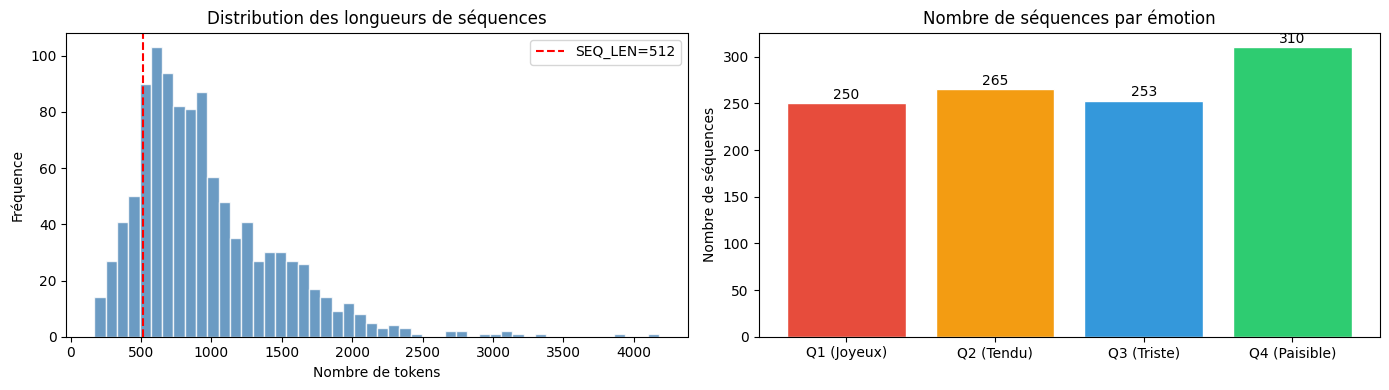

In [ ]:
n_voc = tokenizer.vocab_size
SEQ_LEN = 512 # durée
label_counts = Counter(all_labels)
lengths = [len(t) for t in all_tokens]

print(f"Taille du vocabulaire MidiTok : {n_voc} tokens uniques")
print(f"Nombre total de séquences    : {len(all_tokens)}")
print(f"\nDistribution des émotions :")
for k, v in sorted(label_counts.items()):
    print(f"  Q{k+1} : {v} séquences ({v/len(all_tokens)*100:.1f}%)")
print(f"\nLongueurs des séquences :")
print(f"  Min : {min(lengths)}, Max : {max(lengths)}, Moyenne : {np.mean(lengths):.0f}")

# Histogramme des longueurs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution des longueurs de séquences', fontsize=12)
axes[0].set_xlabel('Nombre de tokens'); axes[0].set_ylabel('Fréquence')
axes[0].axvline(SEQ_LEN, color='red', linestyle='--', label=f'SEQ_LEN={SEQ_LEN}')
axes[0].legend()

# Distribution par émotion
emotion_names = ['Q1 (Joyeux)', 'Q2 (Tendu)', 'Q3 (Triste)', 'Q4 (Paisible)']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = axes[1].bar(emotion_names, [label_counts[i] for i in range(4)], color=colors, edgecolor='white')
axes[1].set_title('Nombre de séquences par émotion', fontsize=12)
axes[1].set_ylabel('Nombre de séquences')
for bar, v in zip(bars, [label_counts[i] for i in range(4)]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(v), ha='center', fontsize=10)
plt.tight_layout(); plt.show()

---
## 3. Préparation du Dataset PyTorch

### Padding et troncature
Les séquences ont des longueurs variables. Pour les traiter en batch, on les uniformise :
- **Troncature** : les séquences > `SEQ_LEN` sont coupées (on perd les dernières notes)
- **Padding** : les séquences < `SEQ_LEN` sont complétées avec des 0 (token de padding)

Le token 0 est ignoré dans la loss (via `ignore_index=0` dans la Cross-Entropy).

### Split train/validation
On sépare 80% pour l'entraînement et 20% pour la validation.
La validation permet de détecter le **surapprentissage** (overfitting).

In [ ]:
def pad_or_truncate(seq, length):
    #Tronque ou padde une séquence à la longueur souhaitée.
    if len(seq) >= length:
        return seq[:length]
    return seq + [0] * (length - len(seq))

data_padded = [pad_or_truncate(t, SEQ_LEN) for t in all_tokens]
X = torch.tensor(data_padded, dtype=torch.long)
Y = torch.tensor(all_labels, dtype=torch.long)

n = len(X)
BATCH_SIZE = 64
torch.manual_seed(42)
perm = torch.randperm(n)
split = int(0.8 * n)
X_train, X_val = X[perm[:split]], X[perm[split:]]
Y_train, Y_val = Y[perm[:split]], Y[perm[split:]]

train_ds = TensorDataset(X_train, Y_train)
val_ds = TensorDataset(X_val, Y_val)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

print(f"Train : {len(train_ds)} séquences")
print(f"Val   : {len(val_ds)} séquences")
print(f"Shape d'un batch : x={next(iter(train_loader))[0].shape}, y={next(iter(train_loader))[1].shape}")

Train : 862 séquences
Val   : 216 séquences
Shape d'un batch : x=torch.Size([64, 512]), y=torch.Size([64])


ON visualise les données en fonction des émotions + embedding :

- PCA (Principal Component Analysis) Ce que ça fait : trouve les 2 axes qui capturent le maximum de variance (= différence entre les données).
Si les 4 émotions sont mélangées --> les émotions ne sont pas distinguables par les features principales
Si les 4 émotions sont séparées --> les données brutes contiennent déjà de l'info sur l'émotion
 - t-SNE (t-distributed Stochastic Neighbor Embedding) Ce que ça fait : préserve les voisinages locaux. Les points proches en 256D restent proches en 2D.


Des clusters d'une même couleur indiquent que les séquences de cette émotion se ressemblent. Si tout mélangé, les émotions ne sont pas clairement différentes dans les données brutes

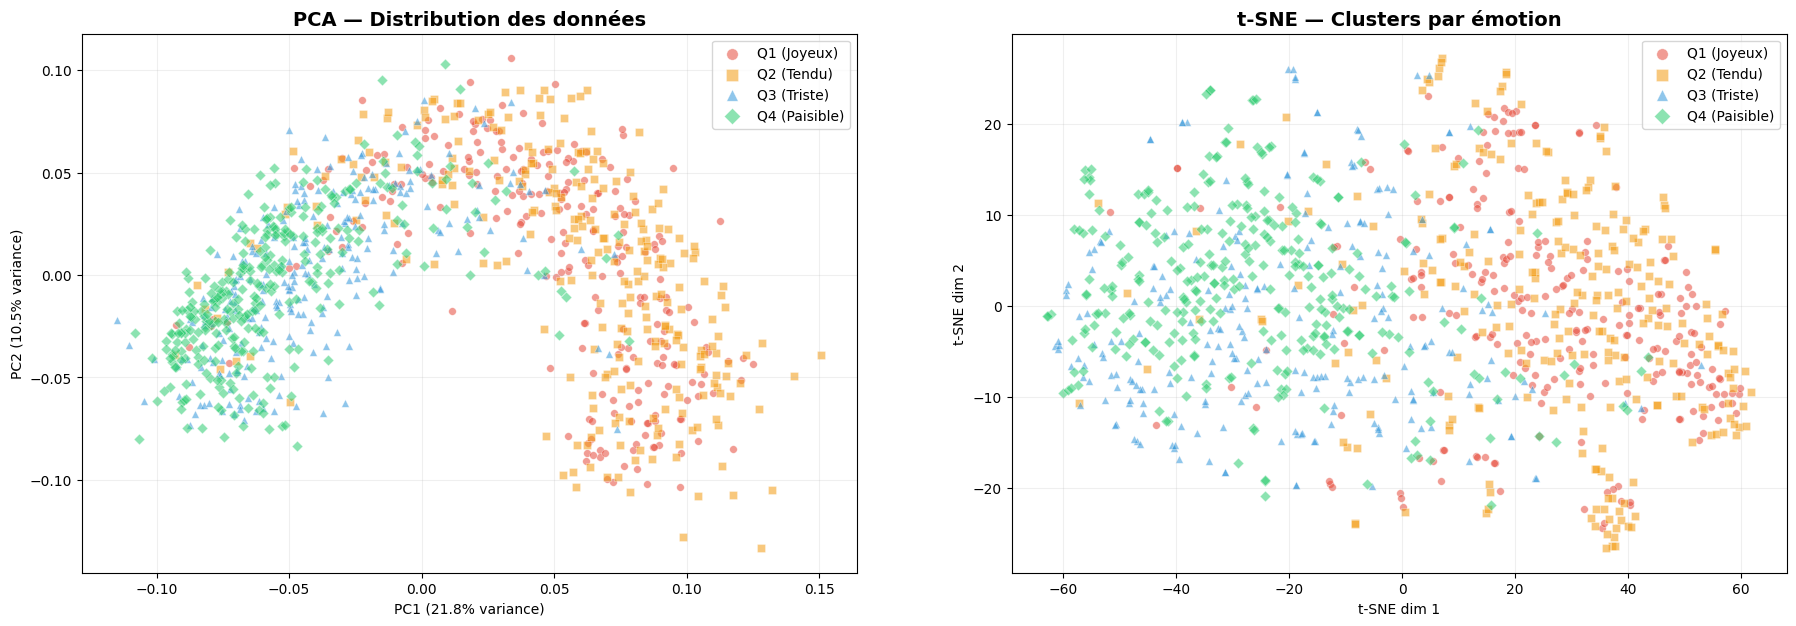

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# On prend les tokens paddés et on les convertit en vecteurs numériques simples

X_np = X.numpy()
bow = np.zeros((len(X_np), n_voc))
for i, seq in enumerate(X_np):
    for tok in seq:
        if tok > 0:  # ignorer le padding
            bow[i, tok] += 1

# Normaliser par la longueur
bow = bow / (bow.sum(axis=1, keepdims=True) + 1e-8)

labels_np = Y.numpy()
emotion_names = ['Q1 (Joyeux)', 'Q2 (Tendu)', 'Q3 (Triste)', 'Q4 (Paisible)']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
markers = ['o', 's', '^', 'D']

# affichage des graphiques
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# PCA
pca = PCA(n_components=2)
z_pca = pca.fit_transform(bow)
for i in range(4):
    mask = labels_np == i
    axes[0].scatter(z_pca[mask, 0], z_pca[mask, 1], c=colors[i], label=emotion_names[i],
                    alpha=0.55, s=30, edgecolors='white', linewidths=0.4, marker=markers[i])
axes[0].set_title('PCA — Distribution des données', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].legend(fontsize=10, markerscale=1.5)
axes[0].grid(alpha=0.2)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(bow)-1))
z_tsne = tsne.fit_transform(bow)
for i in range(4):
    mask = labels_np == i
    axes[1].scatter(z_tsne[mask, 0], z_tsne[mask, 1], c=colors[i], label=emotion_names[i],
                    alpha=0.55, s=30, edgecolors='white', linewidths=0.4, marker=markers[i])
axes[1].set_title('t-SNE — Clusters par émotion', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE dim 1')
axes[1].set_ylabel('t-SNE dim 2')
axes[1].legend(fontsize=10, markerscale=1.5)
axes[1].grid(alpha=0.2)


## 4. Architecture du VAE (Variational Auto-Encoder)


Un VAE apprend à compresser les données dans un espace latent de faible dimension, puis à les reconstruire. Contrairement à un auto-encodeur classique, le VAE impose une structure probabiliste sur l'espace latent :

```
x (tokens sons MIDI) --> Encodeur --> mu (moyenne),
log(σ²) --> z ~ N(μ, σ²) --> Décodeur --> x̂ (reconstruction)

### La reparamétrisation

au lieu d'échantillonner `z ~ N(μ, σ²)`, on reparamétrixe nos variables en calculant:

**z = μ + σ · ε**, où **ε ~ N(0, 1)**

Ainsi le gradient passe par μ et σ, pas par l'échantillonnage.

### 5.1 Fonction de Loss : ELBO


Le VAE maximise l'ELBO (Evidence Lower Bound) :

$$\text{ELBO} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - \text{KL}(q(z|x) \| p(z))$$

On minimise la **loss** = **-ELBO** = **loss de Reconstruction + KL** composée de:

- La loss de Reconstruction : elle mesure à quel point le décodeur reconstruit bien les tokens originaux.
On utilise la **Cross-Entropy** (pour la classification multi-classes) :

$$\mathcal{L}_{\text{recon}} = -\sum_{t=1}^{T} \log p(x_t | z)$$

Le padding (token 0) est ignoré via `ignore_index=0`.

- KL Divergence : elle force l'espace latent à rester proche d'une Gaussienne standard N(0,1).
Pour deux Gaussiennes, la KL suit la formule :

$$\text{KL}(q \| p) = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2\right)$$

Nous avons vu qu'on pouvait utiliser des stratégies d'optimisations du VAE pour permettre de faciliter l'entrainement : nous appliquons donc la méthode du KL Annealing :
Au début de l'entraînement, la KL est pondérée par un facteur **β** qui augmente
de 0 à 1. Cela évite le **KL collapse** (le modèle ignore l'espace latent et
utilise uniquement le décodeur).

#### Pour avoir de bons résultats :
- La **loss reconstruction** doit diminuer fortement (le modèle apprend à reconstruire)
- La **KL** doit augmenter puis se stabiliser (l'espace latent se structure)
- La **loss totale** doit converger

In [ ]:
def vae_loss(logits, targets, mu, logvar, kl_weight=1.0):
  # Calcule la loss ELBO du VAE
  #logits = (B, seq_len, vocab_size) = prédictions du décodeur
  #targets = (B, seq_len) = tokens originaux (ground truth)
  #mu = (B, latent_dim) = moyennes de q(z|x)
  #logvar = (B, latent_dim) = log-variances de q(z|x)
  #kl_weight = float = poids du terme KL (pour le KL annealing)

    B, S, V = logits.shape

    # LOSS Reconstruction : Cross-Entropy (ignore le padding token 0)
    recon_loss = F.cross_entropy(
  logits.reshape(B * S, V),
        targets.reshape(B * S),
        ignore_index=0,                # ignore le padding
        reduction='sum'
    ) / B  # moyenne par échantillon

    # KL Divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B

    total = recon_loss + kl_weight * kl_loss
    return total, recon_loss.item(), kl_loss.item()

### 5.2 Entraînement du VAE

On entraîne le VAE pendant 30 epochs avec :
- **Adam** optimizer (lr=1e-3)
- **Gradient clipping** (max_norm=1.0) — évite les gradients explosifs
- **KL annealing** — le poids du KL augmente linéairement de 0 à 1 sur les 40% premières epochs

On rajoute un
**early stopping** pour arrêter l'entrainement lorsque les poids optimaux sont trouvés

In [ ]:
def train_vae(model, train_loader, val_loader, epochs, lr,save_path, patience=10, kl_anneal=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss':[], 'train_recon':[], 'train_kl':[],
               'val_loss':[], 'val_recon':[], 'val_kl':[]}

    best_val_loss = float('inf')
    best_model_state = None
    wait = 0

    for epoch in range(epochs):
        kl_w = min(1.0, epoch / (epochs * 0.4)) if kl_anneal else 1.0

        model.train()
        t_loss, t_recon, t_kl, n = 0, 0, 0, 0
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            logits, mu, logvar = model(x)
            loss, rl, kl = vae_loss(logits, x, mu, logvar, kl_weight=kl_w)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item(); t_recon += rl; t_kl += kl; n += 1

        model.eval()
        v_loss, v_recon, v_kl, vn = 0, 0, 0, 0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                logits, mu, logvar = model(x)
                loss, rl, kl = vae_loss(logits, x, mu, logvar, kl_weight=kl_w)
                v_loss += loss.item(); v_recon += rl; v_kl += kl; vn += 1

        avg_val = v_loss / vn
        for k, v in [('train_loss',t_loss/n),('train_recon',t_recon/n),('train_kl',t_kl/n),
                      ('val_loss',avg_val),('val_recon',v_recon/vn),('val_kl',v_kl/vn)]:
            history[k].append(v)

        # Early Stopping
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
            marker = "next"
        else:
            wait += 1
            marker = f" ({wait}/{patience})"

        if (epoch+1) % 5 == 0 or wait >= patience:
            print(f"Epoch {epoch+1:3d}/{epochs} | β={kl_w:.2f} | "
                  f"Train: {t_loss/n:.1f} (R:{t_recon/n:.1f} KL:{t_kl/n:.1f}) | "
                  f"Val: {avg_val:.1f}{marker}")

        if wait >= patience:
            print(f"\n Early stopping epoch {epoch+1} | Meilleure val: {best_val_loss:.1f}")
            model.load_state_dict(best_model_state)
            break

    # pour éviter de réentrainer les modèles à chaque fois : sauvegarde des poids
    torch.save(model.state_dict(), save_path)
    print(f"Poids sauvegardés dans : {save_path}")

    return history


### 5.1 Modèle simple : MLP

```
Encodeur:
  tokens (B, 256) --> Embedding (B, 256, 128) --> Flatten (B, 32768)
  --> Linear(32768, 512) --> ReLU --> Dropout(0.2)
  --> Linear(512, 256) --> ReLU
  --> fc_mu: Linear(256, 64)      --> μ
  --> fc_logvar: Linear(256, 64)  --> log(σ²)

Décodeur:
  z (B, 64)
  --> Linear(64, 256) --> ReLU
  --> Linear(256, 512) --> ReLU --> Dropout(0.2)
  --> Linear(512, 256×268) --> Reshape (B, 256, 268)  --> logits sur le vocabulaire
```

In [ ]:
class VAE(nn.Module):
    #VAE avec embedding pour séquences de tokens MIDI
    def __init__(self, vocab_size, seq_len, embed_dim, hidden_dim, latent_dim):
        super().__init__()
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        input_dim = seq_len * embed_dim

        # Couche d'embedding : chaque token vecteur dense
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Encodeur : compresse les données vers l'espace latent
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
        )
        # Deux têtes : une pour mu, une pour log(sigma^2)
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

        # Décodeur : reconstruit les données depuis l'espace latent
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden_dim, seq_len * vocab_size),
        )

    def encode(self, x):
       #Encode les tokens en paramètres de la distribution latente.
        emb = self.embedding(x).view(x.size(0), -1)  # (B, seq_len*embed_dim)
        h = self.encoder(emb)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
       #Reparameterization : z = mu + sigma · eps, eps ~ N(0,1)
        std = torch.exp(0.5 * logvar)   # sigma^2 = exp(log(sigma^2)/2)
        eps = torch.randn_like(std)      # eps suit N(0,1)
        return mu + eps * std

    def decode(self, z):
        #Décode un point latent en logits sur le vocabulaire
        out = self.decoder(z)
        return out.view(-1, self.seq_len, self.vocab_size)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar

    def generate(self, z, max_len=None, temperature=1.0):
        #Génère une séquence pour le MLP
        #max_len est ignoré car la taille est fixe (self.seq_len).

        # Passage dans le décodeur MLP
        logits = self.decode(z) # Forme: (B, seq_len, vocab_size)

        if temperature <= 0:
            generated_tokens = torch.argmax(logits, dim=-1)
        else:
            logits_flat = logits.view(-1, self.vocab_size)
            probs = torch.softmax(logits_flat / temperature, dim=-1)
            tokens_flat = torch.multinomial(probs, num_samples=1)
            generated_tokens = tokens_flat.view(-1, self.seq_len)

        return generated_tokens



In [ ]:
# PARAMETRES
SEQ_LEN = 512 # durée
LATENT_DIM = 64
HIDDEN_DIM = 512
NUM_CLASSES = 4       # Q1, Q2, Q3, Q4
BATCH_SIZE = 64
EPOCHS_VAE = 150
EPOCHS_CVAE = 150
LR = 1e-3
EMBED_DIM = 64

vae_mlp_model = VAE(n_voc, SEQ_LEN, EMBED_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
print(f"Paramètres du modèle : {sum(p.numel() for p in vae_mlp_model.parameters()):,}")

Paramètres du modèle : 87,499,136


In [ ]:
# Entrainement du modèle
print("Entraînement du VAE: \n")
vae_mlp_model = VAE(n_voc, SEQ_LEN, EMBED_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
print(f"Paramètres du modèle : {sum(p.numel() for p in vae_mlp_model.parameters()):,}")

save_path="/content/drive/MyDrive/projet_emopia/projet_emo_propre/model_mlp/weight.pth"
vae_mlp_history = train_vae(vae_mlp_model, train_loader, val_loader, EPOCHS_VAE, LR,save_path)
print("\nEntraînement VAE terminé!!")

Entraînement du VAE: 

Paramètres du modèle : 87,499,136
Epoch   5/150 | β=0.07 | Train: 2180.1 (R:2170.5 KL:143.2) | Val: 2346.9 (1/10)
Epoch  10/150 | β=0.15 | Train: 1752.8 (R:1683.5 KL:462.3) | Val: 2419.1 (6/10)
Epoch  14/150 | β=0.22 | Train: 1412.6 (R:1300.7 KL:516.3) | Val: 2493.9 (10/10)

 Early stopping epoch 14 | Meilleure val: 2346.0
Poids sauvegardés dans : /content/drive/MyDrive/projet_emopia/projet_emo_propre/model_mlp/weight.pth

Entraînement VAE terminé!!


### 5.2 Modèle CNN

In [ ]:
class VAE_CNN(nn.Module):
    #VAE avec encodeur/décodeur CNN 1D pour séquences MIDI
    def __init__(self, vocab_size, seq_len, embed_dim, latent_dim):
        super().__init__()
        self.seq_len = seq_len
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Encodeur CNN
        # Conv1d attend (B, channels, length) --> on utilise embed_dim comme channels
        self.encoder = nn.Sequential(
            nn.Conv1d(embed_dim, 128, kernel_size=8, stride=4, padding=2),  # (B,128,128)
            nn.ReLU(), nn.Dropout(0.3),
            nn.Conv1d(128, 64, kernel_size=4, stride=2, padding=1),         # (B,64,64)
            nn.ReLU(), nn.Dropout(0.3),
            nn.Conv1d(64, 32, kernel_size=4, stride=2, padding=1),          # (B,32,32)
            nn.ReLU(),
            nn.Flatten(),                                                    # (B,1024)
        )

        # Calculer la taille après convolutions
        self._conv_out_size = self._get_conv_output_size(seq_len, embed_dim)
        self.fc_mu = nn.Linear(self._conv_out_size, latent_dim)
        self.fc_logvar = nn.Linear(self._conv_out_size, latent_dim)

        # Décodeur CNN
        self.decoder_fc = nn.Linear(latent_dim, self._conv_out_size)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(), nn.Dropout(0.3),
            nn.ConvTranspose1d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(), nn.Dropout(0.3),
            nn.ConvTranspose1d(128, vocab_size, kernel_size=8, stride=4, padding=2),
        )

    def _get_conv_output_size(self, seq_len, embed_dim):
        #Calcule la taille de sortie des convolutions
        x = torch.zeros(1, embed_dim, seq_len)
        with torch.no_grad():
            for layer in self.encoder:
                x = layer(x)
        return x.shape[1]

    def encode(self, x):
        emb = self.embedding(x)          # (B, seq_len, embed_dim)
        emb = emb.permute(0, 2, 1)       # (B, embed_dim, seq_len) pour Conv1d
        h = self.encoder(emb)            # (B, conv_out_size)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = self.decoder_fc(z)                        # (B, conv_out_size)
        h = h.view(z.size(0), 32, -1)                 # (B, 32, spatial)
        out = self.decoder(h)                          # (B, vocab_size, seq_len)
        out = F.interpolate(out, size=self.seq_len, mode='linear', align_corners=False)
        return out.permute(0, 2, 1)                    # (B, seq_len, vocab_size)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar

    def generate(self, z, max_len=None, temperature=1.0):
          # Génère une séquence pour le CNN
        #max_len est ignoré car défini par l'architecture ConvTranspose1d.
        # Passage dans le décodeur CNN
        logits = self.decode(z) # Forme: (B, seq_len, vocab_size)

        if temperature <= 0:
            generated_tokens = torch.argmax(logits, dim=-1)
        else:
            logits_flat = logits.view(-1, self.vocab_size)
            probs = torch.softmax(logits_flat / temperature, dim=-1)
            tokens_flat = torch.multinomial(probs, num_samples=1)
            generated_tokens = tokens_flat.view(-1, self.seq_len)

        return generated_tokens


In [ ]:
# PARAMETRES
SEQ_LEN = 512 # durée
LATENT_DIM = 64
HIDDEN_DIM = 512
NUM_CLASSES = 4       # Q1, Q2, Q3, Q4
BATCH_SIZE = 64
EPOCHS_VAE = 150
EPOCHS_CVAE = 150
LR = 1e-3
EMBED_DIM = 64

vae_cnn_model = VAE_CNN(n_voc, SEQ_LEN, EMBED_DIM, LATENT_DIM).to(device)
print(f"Paramètres : {sum(p.numel() for p in vae_cnn_model.parameters()):,}")

Paramètres : 637,484


In [ ]:
vae_cnn_model = VAE_CNN(n_voc, SEQ_LEN, EMBED_DIM, LATENT_DIM).to(device)
print(f"Paramètres : {sum(p.numel() for p in vae_cnn_model.parameters()):,}")

# L'entraînement
save_path="/content/drive/MyDrive/projet_emopia/projet_emo_propre/model_cnn/weight.pth"
vae_cnn_history = train_vae(vae_cnn_model, train_loader, val_loader, EPOCHS_VAE, LR,save_path)


Paramètres : 637,484
Epoch   5/150 | β=0.07 | Train: 2323.5 (R:2320.8 KL:40.5) | Val: 2313.7next
Epoch  10/150 | β=0.15 | Train: 2308.2 (R:2305.3 KL:19.0) | Val: 2307.4 (1/10)
Epoch  15/150 | β=0.23 | Train: 2307.2 (R:2304.4 KL:11.9) | Val: 2301.1next
Epoch  20/150 | β=0.32 | Train: 2270.6 (R:2265.5 KL:16.0) | Val: 2257.4next
Epoch  25/150 | β=0.40 | Train: 2245.1 (R:2237.8 KL:18.1) | Val: 2243.9next
Epoch  30/150 | β=0.48 | Train: 2238.5 (R:2230.6 KL:16.4) | Val: 2235.7next
Epoch  35/150 | β=0.57 | Train: 2231.3 (R:2223.0 KL:14.6) | Val: 2233.0 (1/10)
Epoch  40/150 | β=0.65 | Train: 2231.1 (R:2222.7 KL:12.8) | Val: 2231.3 (1/10)
Epoch  45/150 | β=0.73 | Train: 2225.0 (R:2215.9 KL:12.4) | Val: 2225.9next
Epoch  50/150 | β=0.82 | Train: 2216.1 (R:2204.3 KL:14.3) | Val: 2217.2next
Epoch  55/150 | β=0.90 | Train: 2188.5 (R:2165.5 KL:25.5) | Val: 2188.0next
Epoch  60/150 | β=0.98 | Train: 2141.8 (R:2098.6 KL:43.9) | Val: 2132.2next
Epoch  65/150 | β=1.00 | Train: 2092.9 (R:2035.7 KL:57.2) 

### 5.3 Modèle LSTM

In [ ]:
class VAE_LSTM(nn.Module):
    #VAE avec LSTM bidirectionnel pour séquences MIDI

    def __init__(self, vocab_size, seq_len, embed_dim, hidden_dim, latent_dim, num_layers=2):
        super().__init__()
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0) # padding_idx=0 : le token 0 (padding) reste à zéro, non appris

        # Encodeur LSTM
        #   couche 1 = motifs locaux (accords, intervalles)
        #   couche 2 = structure globale (phrases musicales)
        self.encoder_lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers, # num_layers=2 : empiler 2 LSTM permet d'apprendre des abstractions
            batch_first=True,
            dropout=0.3, # régularisation entre les couches LSTM
            bidirectional=True     # la séquence dans les 2 sens --> meilleur contexte
            # 2× hidden_dim en sortie
        )

        # Projection vers mu et log(sigma^2)
        # hidden_dim*2 car bidirectionnel (forward + backward concaténés)
        self.fc_mu = nn.Linear(hidden_dim * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim * 2, latent_dim)

        # Décodeur LSTM
        # PAS bidirectionnel : il génère de gauche à droite (autorégressif)
        # z --> hidden state initial --> LSTM déroule token par token
        self.z_to_hidden = nn.Linear(latent_dim, hidden_dim * num_layers)
        self.z_to_cell = nn.Linear(latent_dim, hidden_dim * num_layers)

        self.decoder_lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3,
            bidirectional=False    # génération séquentielle
        )
        self.output_fc = nn.Linear(hidden_dim, vocab_size)

    def encode(self, x):
        #Lit toute la séquence et produit mu, log(sigma^2)
        emb = self.embedding(x)                          # (B, seq, embed_dim)
        _, (h, _) = self.encoder_lstm(emb)               # h: (num_layers*2, B, hidden)
        # Concaténer forward et backward de la dernière couche
        h_fwd = h[-2]                                     # (B, hidden_dim)
        h_bwd = h[-1]                                     # (B, hidden_dim)
        h_cat = torch.cat([h_fwd, h_bwd], dim=1)         # (B, hidden_dim*2)
        return self.fc_mu(h_cat), self.fc_logvar(h_cat)

    def reparameterize(self, mu, logvar):
        #z = mu + sigma·eps, eps ~ N(0,1)
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def _init_decoder_hidden(self, z):
        #Convertit z en hidden state et cell state du décodeur
        h = self.z_to_hidden(z)                           # (B, hidden*layers)
        c = self.z_to_cell(z)                              # (B, hidden*layers)
        h = h.view(self.num_layers, z.size(0), self.hidden_dim).contiguous()
        c = c.view(self.num_layers, z.size(0), self.hidden_dim).contiguous()
        return h, c

    def decode(self, z, x_input):
        h0, c0 = self._init_decoder_hidden(z)

        # On décale l'entrée d'un cran vers la droite
        # Au lieu de donner [A, B, C, D] pour prédire [A, B, C, D]
        # On donne [0, A, B, C] pour prédire [A, B, C, D]
        B, S = x_input.shape
        start_tokens = torch.zeros(B, 1, dtype=torch.long, device=x_input.device) # token 0
        x_shifted = torch.cat([start_tokens, x_input[:, :-1]], dim=1) # (B, S)

        emb = self.embedding(x_shifted)                   # (B, seq, embed_dim)
        output, _ = self.decoder_lstm(emb, (h0, c0))      # (B, seq, hidden_dim)
        return self.output_fc(output)                     # (B, seq, vocab_size)
      # (B, seq, vocab_size)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z, x)
        return logits, mu, logvar

    def generate(self, z, max_len=512, temperature=0.7):
       #Génère token par token (autorégressif, pour l'inférence)
        h, c = self._init_decoder_hidden(z)
        current = torch.zeros(z.size(0), 1, dtype=torch.long, device=z.device)
        generated = []

        for _ in range(max_len):
            emb = self.embedding(current)
            output, (h, c) = self.decoder_lstm(emb, (h, c))
            logit = self.output_fc(output[:, -1, :])
            probs = F.softmax(logit / temperature, dim=-1)
            next_token = torch.multinomial(probs, 1)
            generated.append(next_token)
            current = next_token

        return torch.cat(generated, dim=1)



In [ ]:
# PARAMETRES
SEQ_LEN = 512 # durée
LATENT_DIM = 64
HIDDEN_DIM = 256
NUM_CLASSES = 4       # Q1, Q2, Q3, Q4
BATCH_SIZE = 64
EPOCHS_VAE = 150
EPOCHS_CVAE = 150
LR = 1e-3
EMBED_DIM = 64
NUM_LAYERS = 2       # 2 couches d'abstraction

vae_LSTM_model = VAE_LSTM(n_voc, SEQ_LEN, EMBED_DIM, HIDDEN_DIM, LATENT_DIM, NUM_LAYERS).to(device)
print(f"Paramètres : {sum(p.numel() for p in vae_LSTM_model.parameters()):,}")

Paramètres : 3,310,732


In [ ]:
# PARAMETRES
SEQ_LEN = 512 # durée
LATENT_DIM = 64
HIDDEN_DIM = 256
NUM_CLASSES = 4       # Q1, Q2, Q3, Q4
BATCH_SIZE = 64
EPOCHS_VAE = 150
EPOCHS_CVAE = 150
LR = 1e-3
EMBED_DIM = 64
NUM_LAYERS = 2       # 2 couches d'abstraction

vae_LSTM_model = VAE_LSTM(n_voc, SEQ_LEN, EMBED_DIM, HIDDEN_DIM, LATENT_DIM, NUM_LAYERS).to(device)
print(f"Paramètres : {sum(p.numel() for p in vae_LSTM_model.parameters()):,}")

# Entraînement (même fonction, rien ne change !)
save_path="/content/drive/MyDrive/projet_emopia/projet_emo_propre/model_lstm/weight.pth"
vae_LSTM_history = train_vae(vae_LSTM_model, train_loader, val_loader, EPOCHS_VAE, LR,save_path)

Paramètres : 3,310,732
Epoch   5/150 | β=0.07 | Train: 2125.8 (R:2125.2 KL:9.6) | Val: 2001.4next
Epoch  10/150 | β=0.15 | Train: 1661.0 (R:1660.4 KL:3.6) | Val: 1644.9next
Epoch  15/150 | β=0.23 | Train: 1595.8 (R:1595.3 KL:2.2) | Val: 1579.6next
Epoch  20/150 | β=0.32 | Train: 1530.7 (R:1530.3 KL:1.5) | Val: 1524.4next
Epoch  25/150 | β=0.40 | Train: 1487.6 (R:1487.3 KL:0.9) | Val: 1480.2next
Epoch  30/150 | β=0.48 | Train: 1453.3 (R:1453.0 KL:0.7) | Val: 1448.5next
Epoch  35/150 | β=0.57 | Train: 1423.2 (R:1422.9 KL:0.5) | Val: 1421.6next
Epoch  40/150 | β=0.65 | Train: 1393.6 (R:1393.4 KL:0.3) | Val: 1390.4next
Epoch  45/150 | β=0.73 | Train: 1361.0 (R:1360.8 KL:0.2) | Val: 1364.2next
Epoch  50/150 | β=0.82 | Train: 1332.2 (R:1332.2 KL:0.1) | Val: 1338.6next
Epoch  55/150 | β=0.90 | Train: 1310.1 (R:1310.1 KL:0.0) | Val: 1322.7next
Epoch  60/150 | β=0.98 | Train: 1291.9 (R:1291.9 KL:0.0) | Val: 1312.7next
Epoch  65/150 | β=1.00 | Train: 1271.7 (R:1271.7 KL:0.0) | Val: 1304.1 (1/10)

## 5. Courbes de loss du VAE


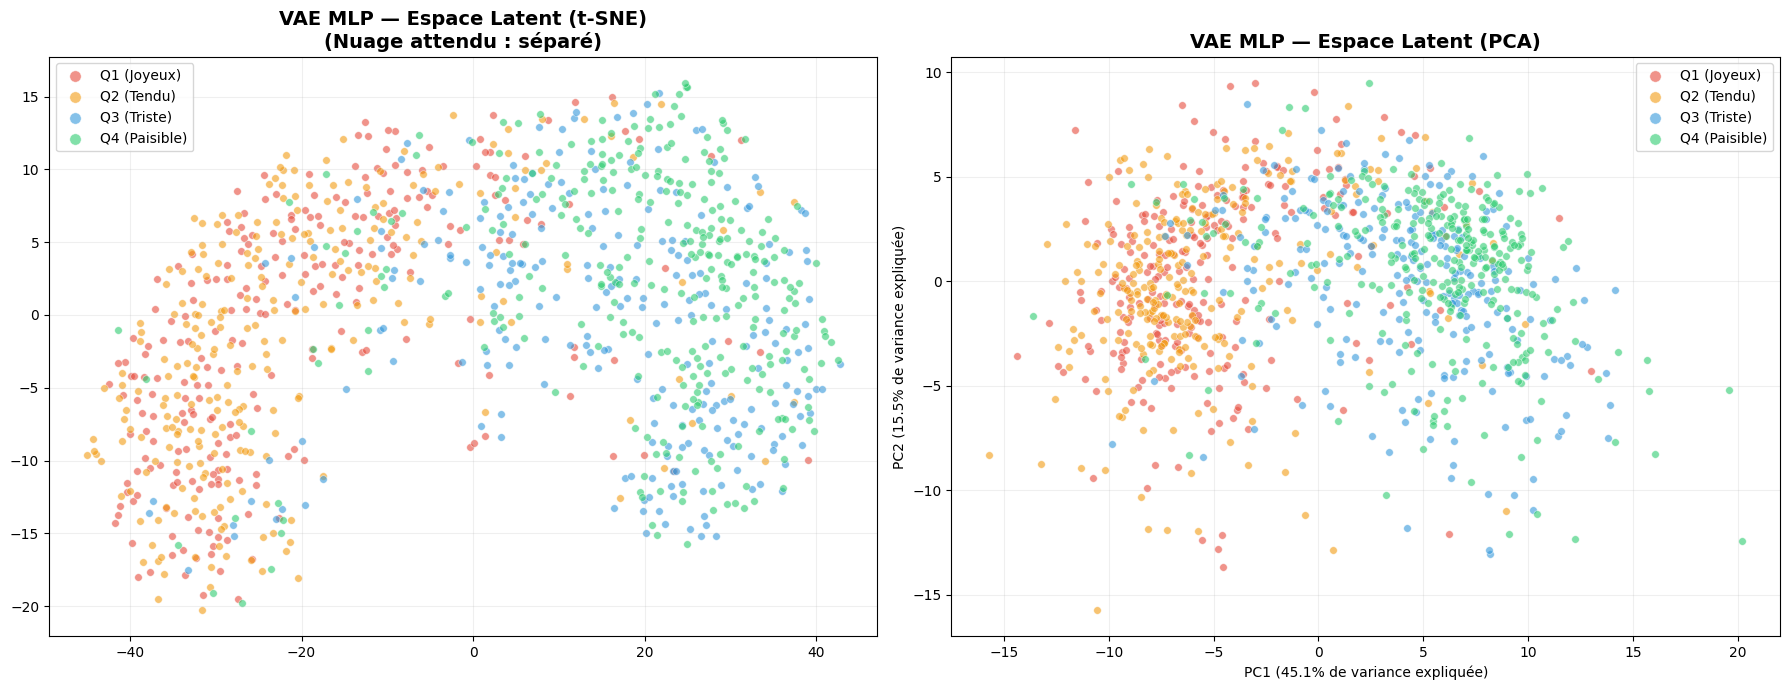


 Silhouette Score : -0.018
  (si 0 = mélangé, > 0.3 = bonne séparation)


In [ ]:
# Visualiser l'espace latent pour le MLP
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np
import torch

#  Collecter les données latentes (mu) pour tout le dataset
vae_mlp_model.eval() # Mettre le modèle en mode évaluation
all_mu, all_labels = [], []

with torch.no_grad():
    for x, y in DataLoader(TensorDataset(X, Y), batch_size=256):
        x = x.to(device)
        # On passe x dans l'encodeur pour obtenir mu et logvar
        mu, _ = vae_mlp_model.encode(x)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

mu_all = np.concatenate(all_mu)
labels_all = np.concatenate(all_labels)

emotion_names = ['Q1 (Joyeux)', 'Q2 (Tendu)', 'Q3 (Triste)', 'Q4 (Paisible)']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# Création de la figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_tsne = tsne.fit_transform(mu_all)

for i in range(4):
    mask = labels_all == i
    axes[0].scatter(z_tsne[mask, 0], z_tsne[mask, 1], c=colors[i],
                    label=emotion_names[i], alpha=0.6, s=30, edgecolors='white', linewidths=0.5)
axes[0].set_title('VAE MLP — Espace Latent (t-SNE)\n(Nuage attendu : séparé)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, markerscale=1.5)
axes[0].grid(alpha=0.2)

# PCA
pca = PCA(n_components=2)
z_pca = pca.fit_transform(mu_all)

for i in range(4):
    mask = labels_all == i
    axes[1].scatter(z_pca[mask, 0], z_pca[mask, 1], c=colors[i],
                    label=emotion_names[i], alpha=0.6, s=30, edgecolors='white', linewidths=0.5)
axes[1].set_title('VAE MLP — Espace Latent (PCA)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} de variance expliquée)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} de variance expliquée)')
axes[1].legend(fontsize=10, markerscale=1.5)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Silhouette Score : Mesure à quel point les clusters (s'il y en a) sont bien séparés.
# Proche de 0 = données mélangées
sil = silhouette_score(mu_all, labels_all)
print(f"\n Silhouette Score : {sil:.3f}")
print("  (si 0 = mélangé, > 0.3 = bonne séparation)")


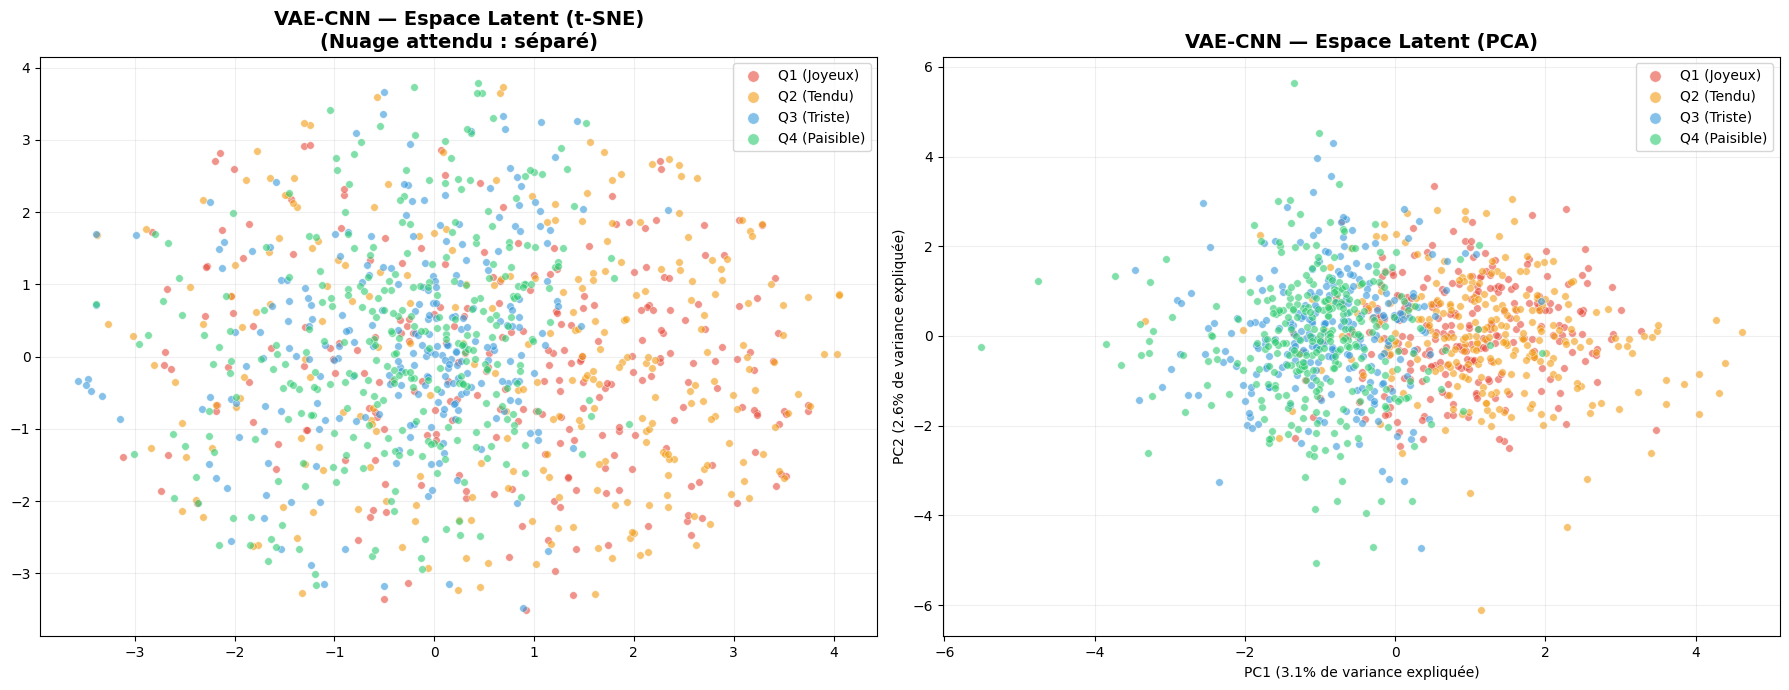


Silhouette Score : -0.007
  (si 0 = mélangé, > 0.3 = bonne séparation)


In [ ]:
# Visualiser l'espace latent pour le CNN
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np
import torch

#  Collecter les données latentes (mu) pour tout le dataset
vae_cnn_model.eval() # Mettre le modèle en mode évaluation
all_mu, all_labels = [], []

with torch.no_grad():
    for x, y in DataLoader(TensorDataset(X, Y), batch_size=256):
        x = x.to(device)
        # On passe x dans l'encodeur pour obtenir mu et logvar
        mu, _ = vae_cnn_model.encode(x)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

mu_all = np.concatenate(all_mu)
labels_all = np.concatenate(all_labels)

emotion_names = ['Q1 (Joyeux)', 'Q2 (Tendu)', 'Q3 (Triste)', 'Q4 (Paisible)']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# Création de la figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_tsne = tsne.fit_transform(mu_all)

for i in range(4):
    mask = labels_all == i
    axes[0].scatter(z_tsne[mask, 0], z_tsne[mask, 1], c=colors[i],
                    label=emotion_names[i], alpha=0.6, s=30, edgecolors='white', linewidths=0.5)
axes[0].set_title('VAE-CNN — Espace Latent (t-SNE)\n(Nuage attendu : séparé)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, markerscale=1.5)
axes[0].grid(alpha=0.2)

# PCA
pca = PCA(n_components=2)
z_pca = pca.fit_transform(mu_all)

for i in range(4):
    mask = labels_all == i
    axes[1].scatter(z_pca[mask, 0], z_pca[mask, 1], c=colors[i],
                    label=emotion_names[i], alpha=0.6, s=30, edgecolors='white', linewidths=0.5)
axes[1].set_title('VAE-CNN — Espace Latent (PCA)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} de variance expliquée)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} de variance expliquée)')
axes[1].legend(fontsize=10, markerscale=1.5)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

#Silhouette Score Mesure à quel point les clusters (s'il y en a) sont bien séparés.
# Proche de 0 = données mélangées (ce qu'on attend du VAE simple)
sil = silhouette_score(mu_all, labels_all)
print(f"\nSilhouette Score : {sil:.3f}")
print("  (si 0 = mélangé, > 0.3 = bonne séparation)")


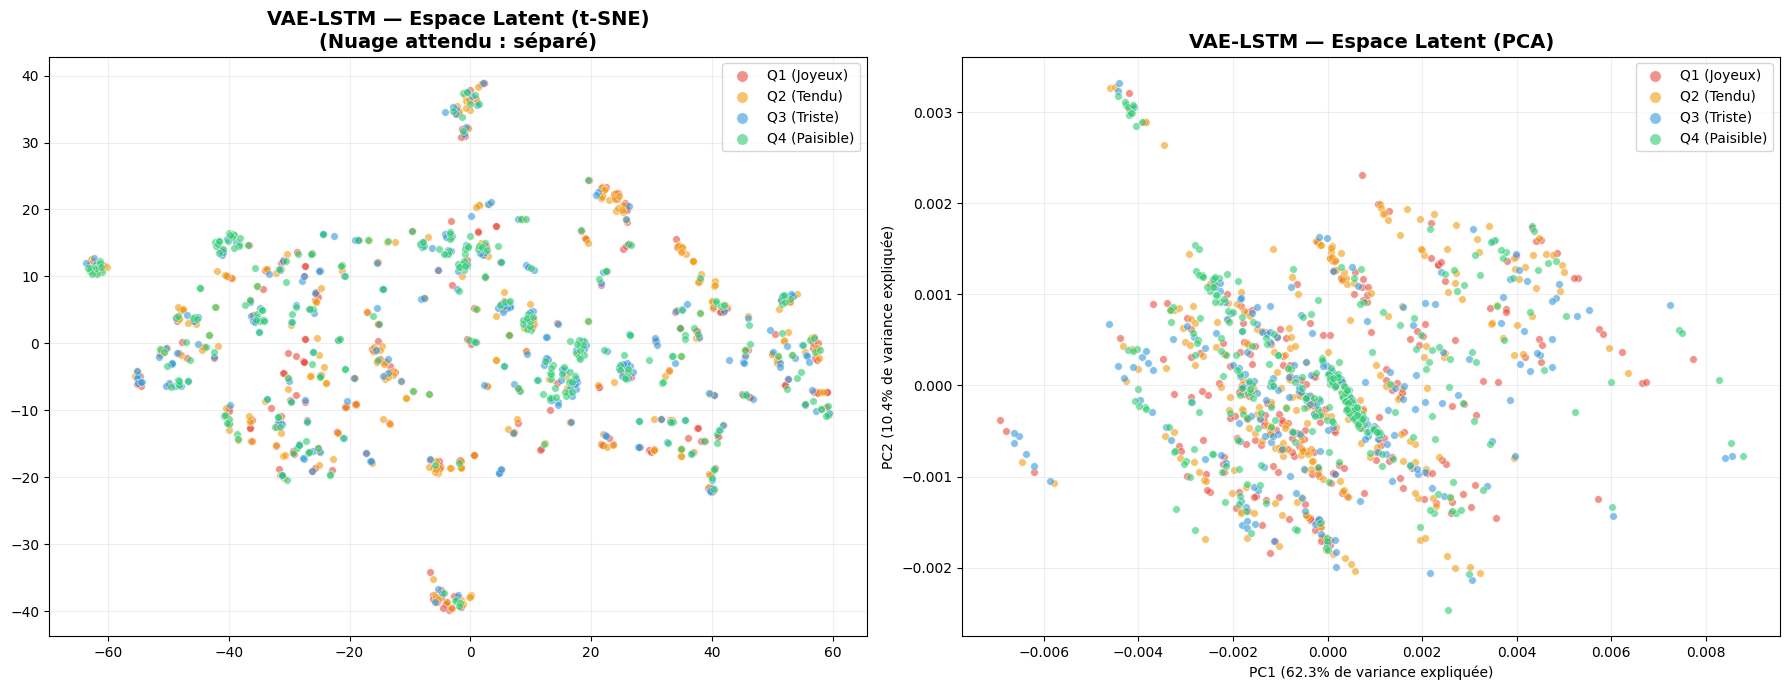


📊 Silhouette Score : -0.009
  (si 0 = mélangé, > 0.3 = bonne séparation)


In [ ]:
# Visualiser l'espace latent pour le LSTM
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np
import torch

# Collecter les données latentes (mu) pour tout le dataset ---
vae_LSTM_model.eval() # Mettre le modèle en mode évaluation
all_mu, all_labels = [], []


with torch.no_grad():
    for x, y in DataLoader(TensorDataset(X, Y), batch_size=256):
        x = x.to(device)
        # On passe x dans l'encodeur pour obtenir mu et logvar
        mu, _ = vae_LSTM_model.encode(x)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

mu_all = np.concatenate(all_mu)
labels_all = np.concatenate(all_labels)

emotion_names = ['Q1 (Joyeux)', 'Q2 (Tendu)', 'Q3 (Triste)', 'Q4 (Paisible)']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# Création de la figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_tsne = tsne.fit_transform(mu_all)

for i in range(4):
    mask = labels_all == i
    axes[0].scatter(z_tsne[mask, 0], z_tsne[mask, 1], c=colors[i],
                    label=emotion_names[i], alpha=0.6, s=30, edgecolors='white', linewidths=0.5)
axes[0].set_title('VAE-LSTM — Espace Latent (t-SNE)\n(Nuage attendu : séparé)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, markerscale=1.5)
axes[0].grid(alpha=0.2)

# PCA
pca = PCA(n_components=2)
z_pca = pca.fit_transform(mu_all)

for i in range(4):
    mask = labels_all == i
    axes[1].scatter(z_pca[mask, 0], z_pca[mask, 1], c=colors[i],
                    label=emotion_names[i], alpha=0.6, s=30, edgecolors='white', linewidths=0.5)
axes[1].set_title('VAE-LSTM — Espace Latent (PCA)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} de variance expliquée)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} de variance expliquée)')
axes[1].legend(fontsize=10, markerscale=1.5)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Silhouette Score : Mesure à quel point les clusters (s'il y en a) sont bien séparés.
# Proche de 0 = données mélangées (ce qu'on attend du VAE simple)
sil = silhouette_score(mu_all, labels_all)
print(f"\n📊 Silhouette Score : {sil:.3f}")
print("  (si 0 = mélangé, > 0.3 = bonne séparation)")


On vérifie que :

La reconstruction diminue (le modèle apprend)
La KL augmente puis se stabilise (l'espace latent se structure)
Pas de divergence train/val excessive (sinon = overfitting)

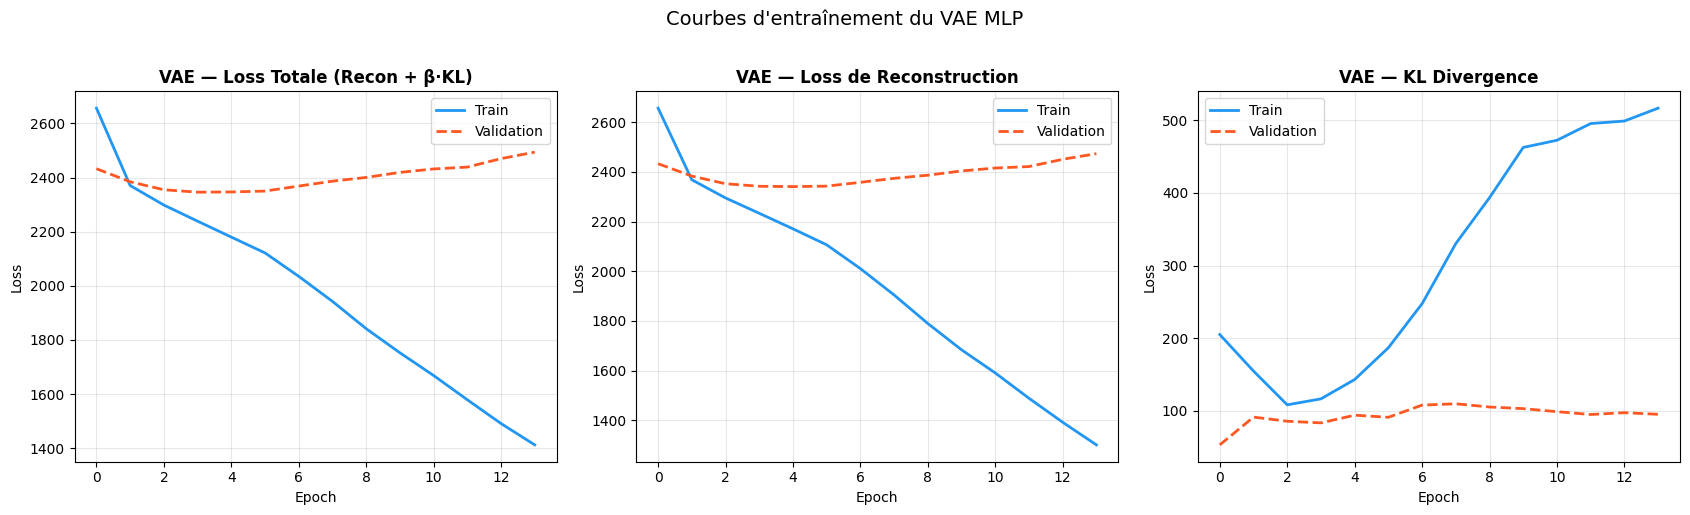

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
titles = ['Loss Totale (Recon + β·KL)', 'Loss de Reconstruction', 'KL Divergence']
keys = ['loss', 'recon', 'kl']

for ax, key, title in zip(axes, keys, titles):
    ax.plot(vae_mlp_history[f'train_{key}'], label='Train', linewidth=2, color='#2196F3')
    ax.plot(vae_mlp_history[f'val_{key}'], label='Validation', linewidth=2, linestyle='--', color='#FF5722')
    ax.set_title(f'VAE — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('Courbes d\'entraînement du VAE MLP', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

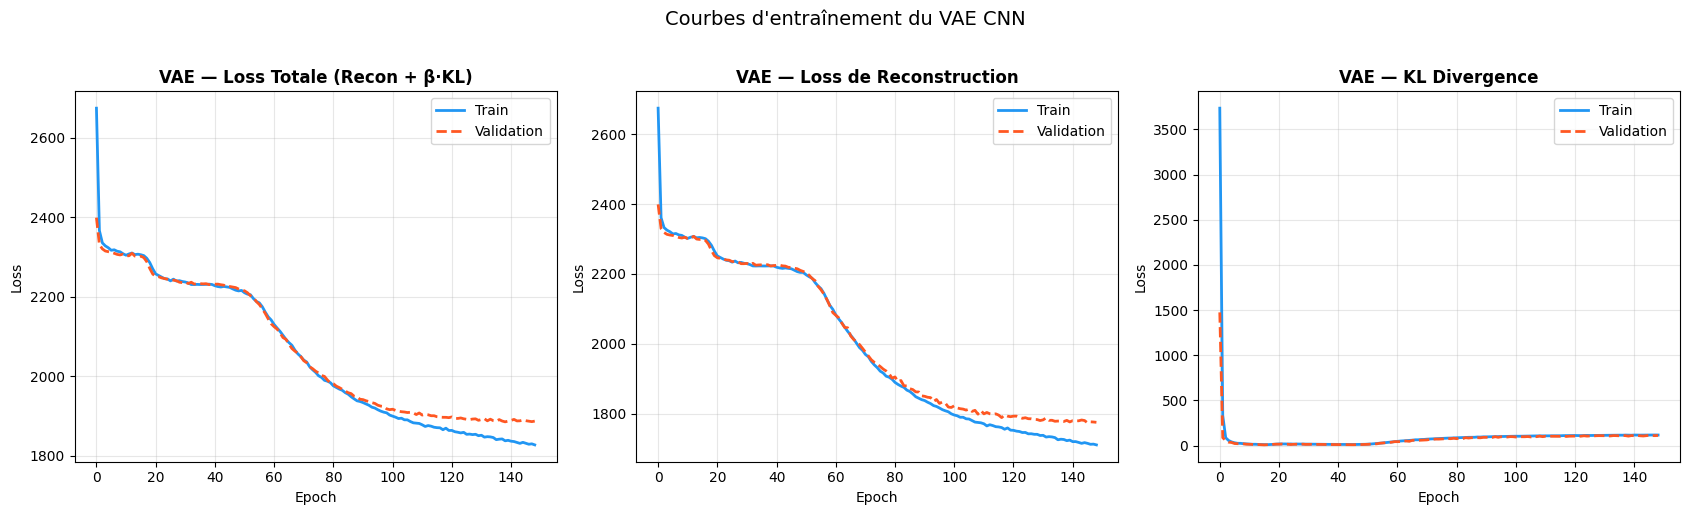

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
titles = ['Loss Totale (Recon + β·KL)', 'Loss de Reconstruction', 'KL Divergence']
keys = ['loss', 'recon', 'kl']

for ax, key, title in zip(axes, keys, titles):
    ax.plot(vae_cnn_history[f'train_{key}'], label='Train', linewidth=2, color='#2196F3')
    ax.plot(vae_cnn_history[f'val_{key}'], label='Validation', linewidth=2, linestyle='--', color='#FF5722')
    ax.set_title(f'VAE — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('Courbes d\'entraînement du VAE CNN', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

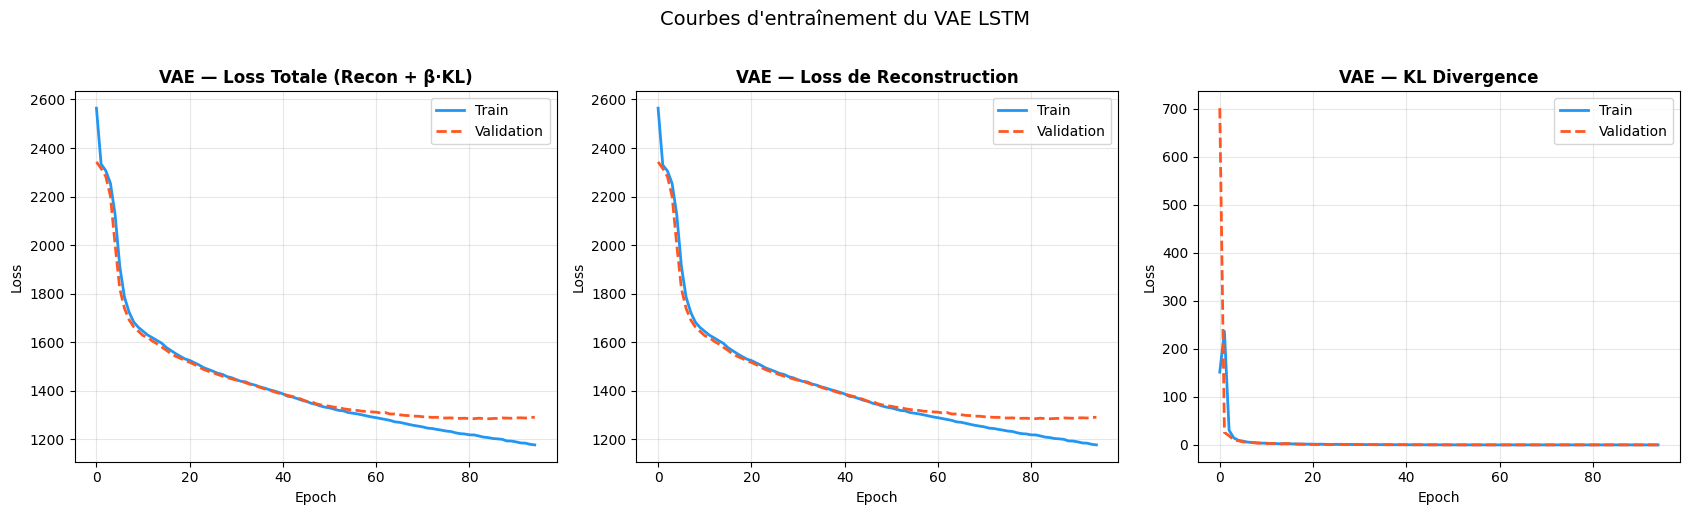

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
titles = ['Loss Totale (Recon + β·KL)', 'Loss de Reconstruction', 'KL Divergence']
keys = ['loss', 'recon', 'kl']

for ax, key, title in zip(axes, keys, titles):
    ax.plot(vae_LSTM_history[f'train_{key}'], label='Train', linewidth=2, color='#2196F3')
    ax.plot(vae_LSTM_history[f'val_{key}'], label='Validation', linewidth=2, linestyle='--', color='#FF5722')
    ax.set_title(f'VAE — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('Courbes d\'entraînement du VAE LSTM', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 6. Génération avec le VAE

In [ ]:
from miditok import TokSequence
def generate_music_by_emotion(target_q, model, tokenizer, save_path, n_samples=2, temperature=0.8):
    """
    target_q  : int (1, 2, 3 ou 4)
    model     : ton VAE_LSTM
    tokenizer : ton tokenizer MidiTok
    save_path : le chemin du dossier où enregistrer
    """
    model.eval()
    os.makedirs(save_path, exist_ok=True) # Crée le dossier s'il n'existe pas

    target_label = target_q - 1
    emotion = ['Joyeux', 'Tendu', 'Triste', 'Paisible']
    emotion_name = emotion[target_label]

    # On calcule le centre de l'émotion dans l'espace latent
    latent_points = []
    with torch.no_grad():
        for x, y in train_loader:
            mu, _ = model.encode(x.to(device))
            mask = (y == target_label)
            if mask.any():
                latent_points.append(mu[mask].cpu())

    all_points = torch.cat(latent_points)
    centroid = all_points.mean(dim=0).to(device)

    print(f"Génération pour Q{target_q} ({emotion_name}) dans : {save_path}")

    with torch.no_grad():
        for s in range(n_samples):
            # On ajoute une variation autour du centre
            z = centroid + torch.randn(1, LATENT_DIM).to(device) * 0.25

            # Génération auto-régressive
            tokens = model.generate(z, max_len=SEQ_LEN, temperature=temperature)

            tok_list = tokens[0].cpu().tolist() if torch.is_tensor(tokens) else tokens
            tok_list = [t for t in tok_list if t != 0]

            try:
                ts = TokSequence(ids=tok_list)
                score = tokenizer.decode([ts])

                # Nom du fichier : Emotion_Qx_SampleX.mid
                file_name = f"{emotion_name}_Q{target_q}_sample_{s}.mid"
                full_path = os.path.join(save_path, file_name)

                score.dump_midi(full_path)
                print(f" {file_name} généré.")
            except Exception as e:
                print(f"Erreur sur {emotion_name} : {e}")

# VAE MLP

OUTPUT_DIR   = "/content/drive/MyDrive/projet_emopia/projet_emo_propre/output_mlp"

for q in range(1, 5): # Boucle de 1 à 4
    generate_music_by_emotion(
        target_q=q,
        model=vae_mlp_model,
        tokenizer=tokenizer,
        save_path=OUTPUT_DIR ,
        n_samples=1,       # 3 morceaux par émotion
        temperature=0.85   # Un peu de créativité
    )

print("\n Fini, tous les fichiers sont dans :", OUTPUT_DIR)

# VAE CNN

OUTPUT_DIR   = "/content/drive/MyDrive/projet_emopia/projet_emo_propre/output_cnn"

for q in range(1, 5): # Boucle de 1 à 4
    generate_music_by_emotion(
        target_q=q,
        model=vae_cnn_model,
        tokenizer=tokenizer,
        save_path=OUTPUT_DIR ,
        n_samples=1,       # 3 morceaux par émotion
        temperature=0.85   # Un peu de créativité
    )

print("\n Fini, tous les fichiers sont dans :", OUTPUT_DIR)

# VAE LSTM

OUTPUT_DIR   = "/content/drive/MyDrive/projet_emopia/projet_emo_propre/output_lstm"

for q in range(1, 5): # Boucle de 1 à 4
    generate_music_by_emotion(
        target_q=q,
        model=vae_LSTM_model,
        tokenizer=tokenizer,
        save_path=OUTPUT_DIR ,
        n_samples=1,       # 3 morceaux par émotion
        temperature=0.85   # Un peu de créativité
    )
print("\n Fini, tous les fichiers sont dans :", OUTPUT_DIR)



Génération pour Q1 (Joyeux) dans : /content/drive/MyDrive/projet_emopia/projet_emo_propre/output_mlp
 Joyeux_Q1_sample_0.mid généré.
Génération pour Q2 (Tendu) dans : /content/drive/MyDrive/projet_emopia/projet_emo_propre/output_mlp
 Tendu_Q2_sample_0.mid généré.
Génération pour Q3 (Triste) dans : /content/drive/MyDrive/projet_emopia/projet_emo_propre/output_mlp
 Triste_Q3_sample_0.mid généré.
Génération pour Q4 (Paisible) dans : /content/drive/MyDrive/projet_emopia/projet_emo_propre/output_mlp
 Paisible_Q4_sample_0.mid généré.

 Fini, tous les fichiers sont dans : /content/drive/MyDrive/projet_emopia/projet_emo_propre/output_mlp
Génération pour Q1 (Joyeux) dans : /content/drive/MyDrive/projet_emopia/projet_emo_propre/output_cnn
 Joyeux_Q1_sample_0.mid généré.
Génération pour Q2 (Tendu) dans : /content/drive/MyDrive/projet_emopia/projet_emo_propre/output_cnn
 Tendu_Q2_sample_0.mid généré.
Génération pour Q3 (Triste) dans : /content/drive/MyDrive/projet_emopia/projet_emo_propre/output_c

## 7. C-VAE

In [ ]:
# C -VAE
class CVAE_LSTM(nn.Module):
    def __init__(self, vocab_size, seq_len, embed_dim, hidden_dim, latent_dim, num_classes, num_layers=2):
        super().__init__()
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_classes = num_classes

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0) #embedding

        self.encoder_lstm = nn.LSTM( #encodeur bidirectionnel cf + haut
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True, dropout=0.3, bidirectional=True
        )
        self.fc_mu = nn.Linear(hidden_dim * 2 + num_classes, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim * 2 + num_classes, latent_dim)

        self.z_to_hidden = nn.Linear(latent_dim + num_classes, hidden_dim * num_layers)
        self.z_to_cell = nn.Linear(latent_dim + num_classes, hidden_dim * num_layers)

        self.decoder_lstm = nn.LSTM(
            input_size=embed_dim + num_classes, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True, dropout=0.3, bidirectional=False
        )
        self.output_fc = nn.Linear(hidden_dim, vocab_size)

    def encode(self, x, c): #decodeur
        emb = self.embedding(x) #embedding
        _, (h, _) = self.encoder_lstm(emb)
        h_cat = torch.cat([h[-2], h[-1]], dim=1)
        h_cond = torch.cat([h_cat, c], dim=1)
        return self.fc_mu(h_cond), self.fc_logvar(h_cond)

    def reparameterize(self, mu, logvar): #reparametrisation
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def _init_decoder_hidden(self, z, c): #Initialise les états du décodeur en combinant le vecteur latent z et la condition c
        z_cond = torch.cat([z, c], dim=1)
        h = self.z_to_hidden(z_cond).view(self.num_layers, z.size(0), self.hidden_dim).contiguous()
        cell = self.z_to_cell(z_cond).view(self.num_layers, z.size(0), self.hidden_dim).contiguous()
        return h, cell

    def decode(self, z, c, x_input): #decodeur
        h0, c0 = self._init_decoder_hidden(z, c)

        B, S = x_input.shape # Décalage de la séquence : on ajoute un token de départ (0) au début et on enlève le dernier mot.
        # Le modèle doit prédire le mot N à partir des mots 0 à N-1. cf VAE LSTM + haut
        start_tokens = torch.zeros(B, 1, dtype=torch.long, device=x_input.device)
        x_shifted = torch.cat([start_tokens, x_input[:, :-1]], dim=1)

        emb = self.embedding(x_shifted)
        c_expanded = c.unsqueeze(1).expand(-1, S, -1) #La condition c est répétée pour chaque mot de la séquence + concaténée à l'embedding avant de passer dans le décodeur.
        emb_cond = torch.cat([emb, c_expanded], dim=2)

        output, _ = self.decoder_lstm(emb_cond, (h0, c0))
        return self.output_fc(output)

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z, c, x)
        return logits, mu, logvar

    def generate(self, z, c, max_len=512, temperature=0.7):
        h, cell = self._init_decoder_hidden(z, c)
        current = torch.zeros(z.size(0), 1, dtype=torch.long, device=z.device)
        generated = []
        c_step = c.unsqueeze(1)

        for _ in range(max_len):
            emb = self.embedding(current)
            emb_cond = torch.cat([emb, c_step], dim=2)
            output, (h, cell) = self.decoder_lstm(emb_cond, (h, cell))
            logit = self.output_fc(output[:, -1, :])
            probs = F.softmax(logit / temperature, dim=-1)
            next_token = torch.multinomial(probs, 1)
            generated.append(next_token)
            current = next_token # Le mot généré devient l'entrée de la boucle suivante

        return torch.cat(generated, dim=1)


In [ ]:
import os
import torch
import torch.optim as optim

def get_one_hot(labels, num_classes): # Transforme un label entier en vecteur binaire one-hot" --> ici c'est la condition pour le C_VAE
    return F.one_hot(labels, num_classes=num_classes).float()

def train_cvae(model, train_loader, val_loader, epochs, lr, save_path, patience=10, kl_anneal=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Comme pour le VAE
    history = {'train_loss':[], 'train_recon':[], 'train_kl':[],
               'val_loss':[], 'val_recon':[], 'val_kl':[]}

    best_val_loss = float('inf') #pour le early stopping
    best_model_state = None
    wait = 0

    for epoch in range(epochs):
        # comme plus haut pour le KL Annealing
        kl_w = min(1.0, epoch / (epochs * 0.4)) if kl_anneal else 1.0


        # entrainement
        model.train()
        t_loss, t_recon, t_kl, n = 0, 0, 0, 0
        for x, y in train_loader:
            x = x.to(device)
            c = get_one_hot(y, NUM_CLASSES).to(device) # transforme le label en vecteur

            optimizer.zero_grad()
            logits, mu, logvar = model(x, c) #ici différence avec VAE : prend 2 entrées
            loss, rl, kl = vae_loss(logits, x, mu, logvar, kl_weight=kl_w)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            t_loss += loss.item()
            t_recon += rl
            t_kl += kl
            n += 1

        #validation
        model.eval()
        v_loss, v_recon, v_kl, vn = 0, 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                c = get_one_hot(y, NUM_CLASSES).to(device) # Injection de la condition

                logits, mu, logvar = model(x, c)
                loss, rl, kl = vae_loss(logits, x, mu, logvar, kl_weight=kl_w)

                v_loss += loss.item()
                v_recon += rl
                v_kl += kl
                vn += 1

        avg_val = v_loss / vn

        # Remplissage de l'historique
        for k, v in [('train_loss', t_loss/n), ('train_recon', t_recon/n), ('train_kl', t_kl/n),
                      ('val_loss', avg_val), ('val_recon', v_recon/vn), ('val_kl', v_kl/vn)]:
            history[k].append(v)

        # Early Stopping identique au VAE
        if avg_val < best_val_loss:
            best_val_loss = avg_val # Sauvegarde les meilleurs poids en mémoire
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
            marker = "next" #signifie qu'il y a eu amélioration
        else:
            wait += 1
            marker = f" ({wait}/{patience})"

        # 5. Affichage toutes les 5 epochs
        if (epoch+1) % 5 == 0 or wait >= patience:
            print(f"Epoch {epoch+1:3d}/{epochs} | β={kl_w:.2f} | "
                  f"Train: {t_loss/n:.1f} (R:{t_recon/n:.1f} KL:{t_kl/n:.1f}) | "
                  f"Val: {avg_val:.1f}{marker}")


        if wait >= patience: #early stopping
            print(f"\n Early stopping epoch {epoch+1} | Meilleure val: {best_val_loss:.1f}")
            model.load_state_dict(best_model_state)
            break

    # sauvegarde des poids
    dir_name = os.path.dirname(save_path)
    if dir_name:
        os.makedirs(dir_name, exist_ok=True)

    torch.save(model.state_dict(), save_path)
    print(f" Entraînement terminé. Poids sauvegardés dans : {save_path}")

    return history

In [ ]:
# PARAMETRES
SEQ_LEN = 512 # durée
LATENT_DIM = 64
HIDDEN_DIM = 256
NUM_CLASSES = 4       # Q1, Q2, Q3, Q4
BATCH_SIZE = 64
EPOCHS_VAE = 150
EPOCHS_CVAE = 150
LR = 1e-3
EMBED_DIM = 64
NUM_LAYERS = 2       # 2 couches d'abstraction

cvae_model = CVAE_LSTM(n_voc, SEQ_LEN, EMBED_DIM, HIDDEN_DIM, LATENT_DIM, NUM_CLASSES).to(device)
print(f"Paramètres CVAE LSTM : {sum(p.numel() for p in cvae_model.parameters()):,}")

Paramètres CVAE LSTM : 3,319,436


In [ ]:
print("Entraînement du CVAE")
cvae_model = CVAE_LSTM(n_voc, SEQ_LEN, EMBED_DIM, HIDDEN_DIM, LATENT_DIM, NUM_CLASSES).to(device)

save_path="/content/drive/MyDrive/projet_emopia/projet_emo_propre/model_mlp/weight.pth"
cvae_history = train_cvae(cvae_model, train_loader, val_loader, epochs=EPOCHS_CVAE, lr=LR,save_path=save_path, patience=15)
print("\nEntraînement VAE terminé !")

Entraînement du CVAE
Epoch   5/150 | β=0.07 | Train: 2230.2 (R:2229.6 KL:9.0) | Val: 2162.7next
Epoch  10/150 | β=0.15 | Train: 1673.9 (R:1673.4 KL:3.3) | Val: 1658.9next
Epoch  15/150 | β=0.23 | Train: 1620.2 (R:1619.8 KL:1.7) | Val: 1610.2next
Epoch  20/150 | β=0.32 | Train: 1581.6 (R:1581.2 KL:1.3) | Val: 1571.3next
Epoch  25/150 | β=0.40 | Train: 1529.3 (R:1529.0 KL:0.8) | Val: 1524.7next
Epoch  30/150 | β=0.48 | Train: 1482.2 (R:1482.1 KL:0.4) | Val: 1478.0next
Epoch  35/150 | β=0.57 | Train: 1447.5 (R:1447.4 KL:0.2) | Val: 1445.0next
Epoch  40/150 | β=0.65 | Train: 1421.2 (R:1421.2 KL:0.1) | Val: 1419.8next
Epoch  45/150 | β=0.73 | Train: 1390.8 (R:1390.8 KL:0.0) | Val: 1390.4next
Epoch  50/150 | β=0.82 | Train: 1356.8 (R:1356.7 KL:0.0) | Val: 1356.6next
Epoch  55/150 | β=0.90 | Train: 1328.9 (R:1328.9 KL:0.0) | Val: 1336.9next
Epoch  60/150 | β=0.98 | Train: 1309.4 (R:1309.4 KL:0.0) | Val: 1323.4next
Epoch  65/150 | β=1.00 | Train: 1287.8 (R:1287.8 KL:0.0) | Val: 1312.6next
Epoc

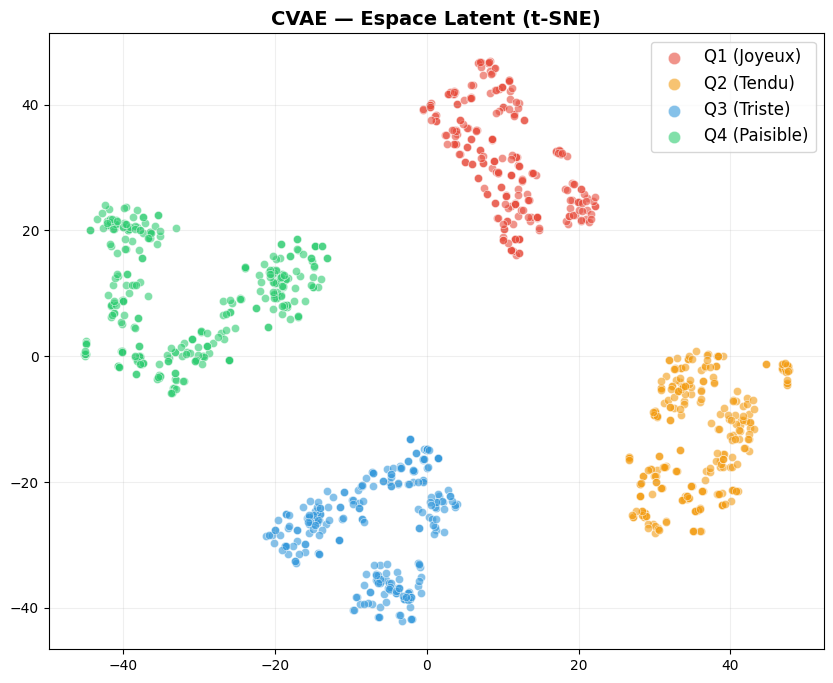

 Silhouette Score : 0.855


In [ ]:
# Visualisation de l'espace latent du CVAE t-SNE
from sklearn.metrics import silhouette_score

cvae_model.eval()
all_mu, all_labels = [], []

with torch.no_grad():
    for x, y in DataLoader(TensorDataset(X, Y), batch_size=BATCH_SIZE):
        x = x.to(device)
        c = get_one_hot(y, NUM_CLASSES).to(device)
        mu, _ = cvae_model.encode(x, c)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

mu_all = np.concatenate(all_mu)
labels_all = np.concatenate(all_labels)

emotion_names = ['Q1 (Joyeux)', 'Q2 (Tendu)', 'Q3 (Triste)', 'Q4 (Paisible)']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_tsne = tsne.fit_transform(mu_all)

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    mask = labels_all == i
    plt.scatter(z_tsne[mask, 0], z_tsne[mask, 1], c=colors[i],
                label=emotion_names[i], alpha=0.6, s=35, edgecolors='white', linewidths=0.5)

plt.title('CVAE — Espace Latent (t-SNE)', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, markerscale=1.5)
plt.grid(alpha=0.2)
plt.show()

sil = silhouette_score(mu_all, labels_all)
print(f" Silhouette Score : {sil:.3f}")


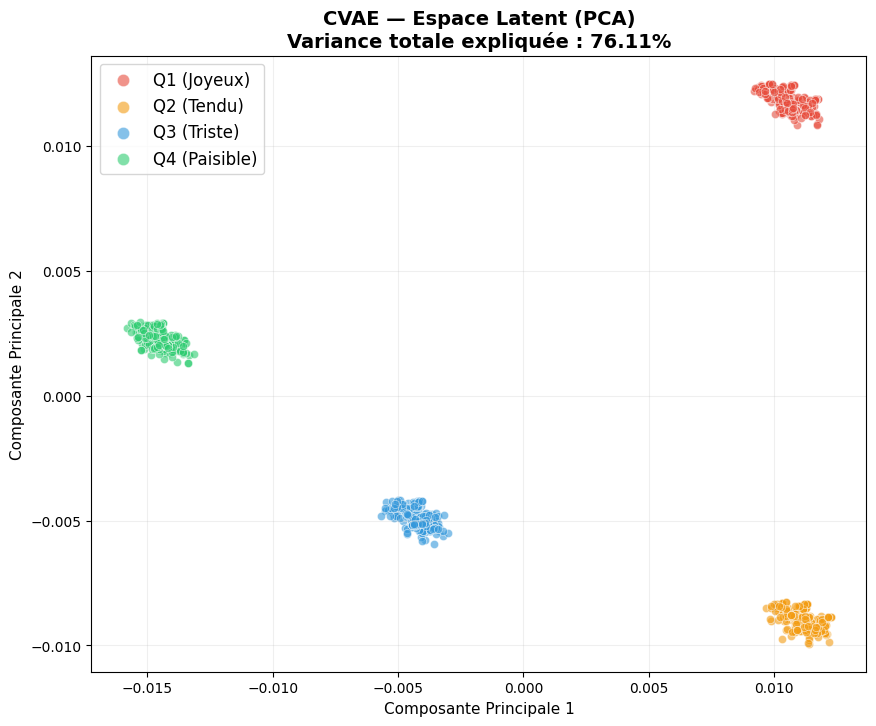

Silhouette Score : 0.855


In [ ]:
# Visulatisation de l'espace Latent PCA
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

cvae_model.eval()
all_mu, all_labels = [], []

with torch.no_grad():
    for x, y in DataLoader(TensorDataset(X, Y), batch_size=BATCH_SIZE):
        x = x.to(device)
        c = get_one_hot(y, NUM_CLASSES).to(device)
        mu, _ = cvae_model.encode(x, c)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

mu_all = np.concatenate(all_mu)
labels_all = np.concatenate(all_labels)

emotion_names = ['Q1 (Joyeux)', 'Q2 (Tendu)', 'Q3 (Triste)', 'Q4 (Paisible)']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

pca = PCA(n_components=2, random_state=42)
z_pca = pca.fit_transform(mu_all)

# Calcul de la variance expliquée pour l'afficher dans le titre
variance_expliquee = np.sum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    mask = labels_all == i
    plt.scatter(z_pca[mask, 0], z_pca[mask, 1], c=colors[i],
                label=emotion_names[i], alpha=0.6, s=35, edgecolors='white', linewidths=0.5)

# Mise à jour des titres pour la PCA
plt.title(f'CVAE — Espace Latent (PCA)\nVariance totale expliquée : {variance_expliquee:.2f}%', fontsize=14, fontweight='bold')
plt.xlabel('Composante Principale 1', fontsize=11)
plt.ylabel('Composante Principale 2', fontsize=11)
plt.legend(fontsize=12, markerscale=1.5)
plt.grid(alpha=0.2)
plt.show()

# Le score de Silhouette reste calculé sur "mu_all" (l'espace complet), ce qui est parfait.
sil = silhouette_score(mu_all, labels_all)
print(f"Silhouette Score : {sil:.3f}")

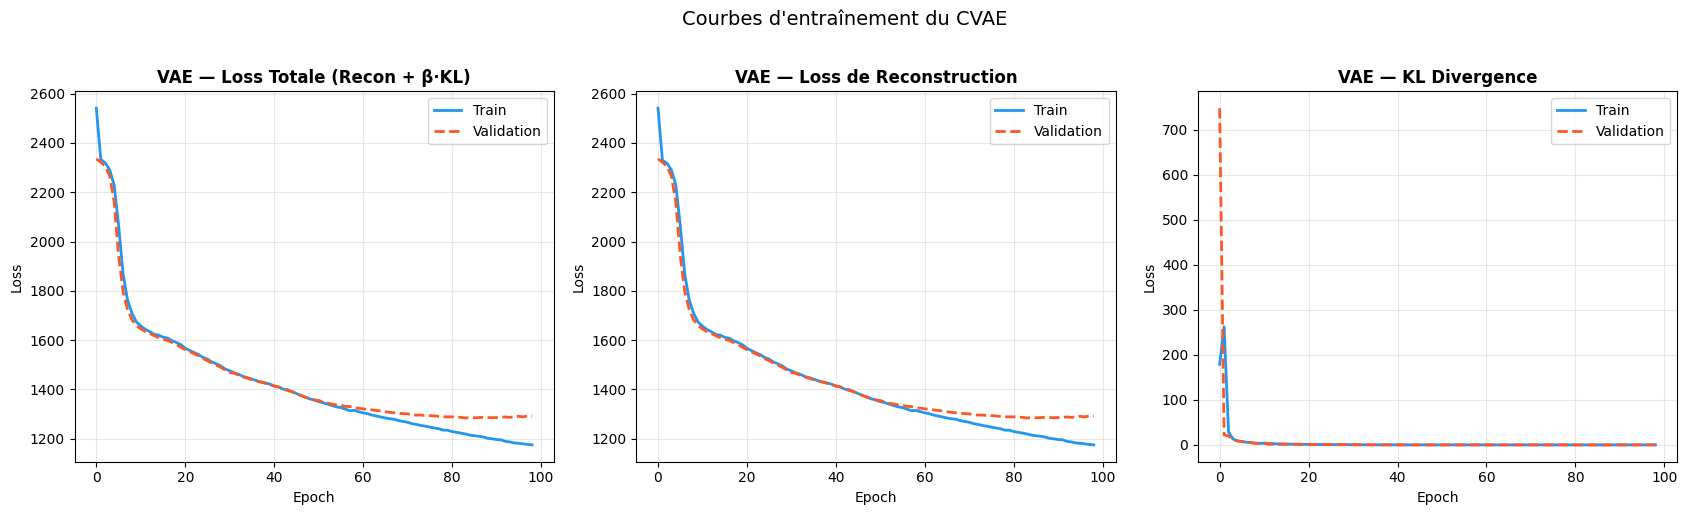

In [ ]:
#Métriques de Loss

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
titles = ['Loss Totale (Recon + β·KL)', 'Loss de Reconstruction', 'KL Divergence']
keys = ['loss', 'recon', 'kl']

for ax, key, title in zip(axes, keys, titles):
    ax.plot(cvae_history[f'train_{key}'], label='Train', linewidth=2, color='#2196F3')
    ax.plot(cvae_history[f'val_{key}'], label='Validation', linewidth=2, linestyle='--', color='#FF5722')
    ax.set_title(f'VAE — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('Courbes d\'entraînement du CVAE', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
from miditok import TokSequence
def generate_music_by_emotion_cvae(target_q, model, tokenizer, save_path, n_samples=2, temperature=0.8):
    model.eval()
    target_label=target_q-1
    emotion_name = emotion_names[target_label]
    print(f"\n Génération de {n_samples} musiques pour l'émotion : {emotion_name}")

    with torch.no_grad():
        c = get_one_hot(torch.tensor([target_label]), NUM_CLASSES).to(device)
        for s in range(n_samples):
            z = torch.randn(1, LATENT_DIM).to(device)
            tokens = model.generate(z, c, max_len=SEQ_LEN, temperature=temperature)

            tok_list = [t for t in tokens[0].cpu().tolist() if t != 0]
            tok_list = [max(0, min(t, n_voc - 1)) for t in tok_list]

            try:
                ts = TokSequence(ids=tok_list)
                score = tokenizer.decode([ts])

                # Nom du fichier : Emotion_Qx_SampleX.mid
                file_name = f"{emotion_name}_Q{target_q}_sample_{s}.mid"
                full_path = os.path.join(save_path, file_name)

                score.dump_midi(full_path)
                print(f"  {file_name} généré.")

            except Exception as e:
                print(f"   Erreur sur {emotion_name} : {e}")




In [ ]:
# Choisis ton dossier ici
OUTPUT_DIR   = "/content/drive/MyDrive/projet_emopia/projet_emo_propre/output_cvae"

for q in range(1, 5): # Boucle de 1 à 4
    generate_music_by_emotion_cvae(
        target_q=q,
        model=cvae_model,
        tokenizer=tokenizer,
        save_path=OUTPUT_DIR ,
        n_samples=1,       # 3 morceaux par émotion
        temperature=0.85   # Un peu de créativité
    )

print("\n fini, fichiers dans :", OUTPUT_DIR)


 Génération de 1 musiques pour l'émotion : Q1 (Joyeux)
  Q1 (Joyeux)_Q1_sample_0.mid généré.

 Génération de 1 musiques pour l'émotion : Q2 (Tendu)
  Q2 (Tendu)_Q2_sample_0.mid généré.

 Génération de 1 musiques pour l'émotion : Q3 (Triste)
  Q3 (Triste)_Q3_sample_0.mid généré.

 Génération de 1 musiques pour l'émotion : Q4 (Paisible)
  Q4 (Paisible)_Q4_sample_0.mid généré.

 fini, fichiers dans : /content/drive/MyDrive/projet_emopia/projet_emo_propre/output_cvae


# Recharger un modèle sauvegardé

In [ ]:
# VAE MLP

MODEL_PATH="/content/drive/MyDrive/projet_emopia/projet_emo_propre/model_mlp/weight.pth"

checkpoint = torch.load(MODEL_PATH, map_location=device)
model = VAE(n_voc, SEQ_LEN, EMBED_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
model.load_state_dict(checkpoint)
model.eval()
print(f"Modèle rechargé depuis {MODEL_PATH}")

RuntimeError: Error(s) in loading state_dict for VAE:
	size mismatch for encoder.0.weight: copying a param with shape torch.Size([256, 32768]) from checkpoint, the shape in current model is torch.Size([512, 32768]).
	size mismatch for encoder.0.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([512]).
	size mismatch for encoder.3.weight: copying a param with shape torch.Size([128, 256]) from checkpoint, the shape in current model is torch.Size([256, 512]).
	size mismatch for encoder.3.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for fc_mu.weight: copying a param with shape torch.Size([32, 128]) from checkpoint, the shape in current model is torch.Size([32, 256]).
	size mismatch for fc_logvar.weight: copying a param with shape torch.Size([32, 128]) from checkpoint, the shape in current model is torch.Size([32, 256]).
	size mismatch for decoder

In [ ]:
# VAE CNN

MODEL_PATH="/content/drive/MyDrive/projet_emopia/projet_emo_propre/model_cnn/weight.pth"

checkpoint = torch.load(MODEL_PATH, map_location=device)
model = VAE_CNN(n_voc, SEQ_LEN, EMBED_DIM, LATENT_DIM).to(device)
model.load_state_dict(checkpoint)
model.eval()
print(f"Modèle rechargé depuis {MODEL_PATH}")

In [ ]:
#VAE LSTM

MODEL_PATH="/content/drive/MyDrive/projet_emopia/projet_emo_propre/model_lstm/weight.pth"

checkpoint = torch.load(MODEL_PATH, map_location=device)
model = VAE_LSTM(n_voc, SEQ_LEN, EMBED_DIM, HIDDEN_DIM, LATENT_DIM, NUM_LAYERS).to(device)
model.load_state_dict(checkpoint)
model.eval()
print(f"Modèle rechargé depuis {MODEL_PATH}")

In [ ]:
#CVAE

MODEL_PATH="/content/drive/MyDrive/projet_emopia/projet_emo_propre/model_cvae/weight.pth"

checkpoint = torch.load(MODEL_PATH, map_location=device)
model = CVAE_LSTM(n_voc, SEQ_LEN, EMBED_DIM, HIDDEN_DIM, LATENT_DIM, NUM_CLASSES).to(device)
model.load_state_dict(checkpoint)
model.eval()
print(f" Modèle rechargé depuis {MODEL_PATH}")